# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [145]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
import joblib

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [146]:
# Load data
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)

In [147]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [148]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [149]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

Text(0.5, 1.0, 'Correlation Matrix')

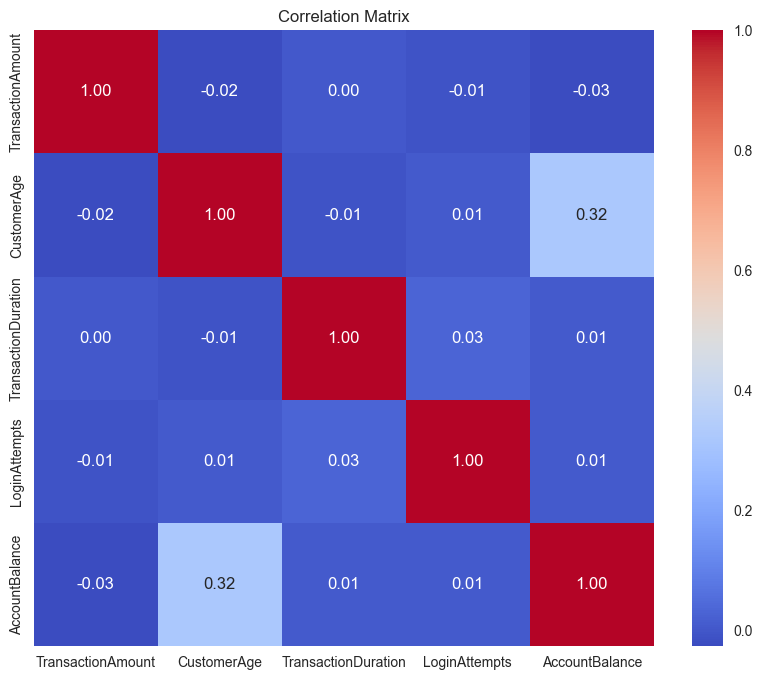

In [150]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')

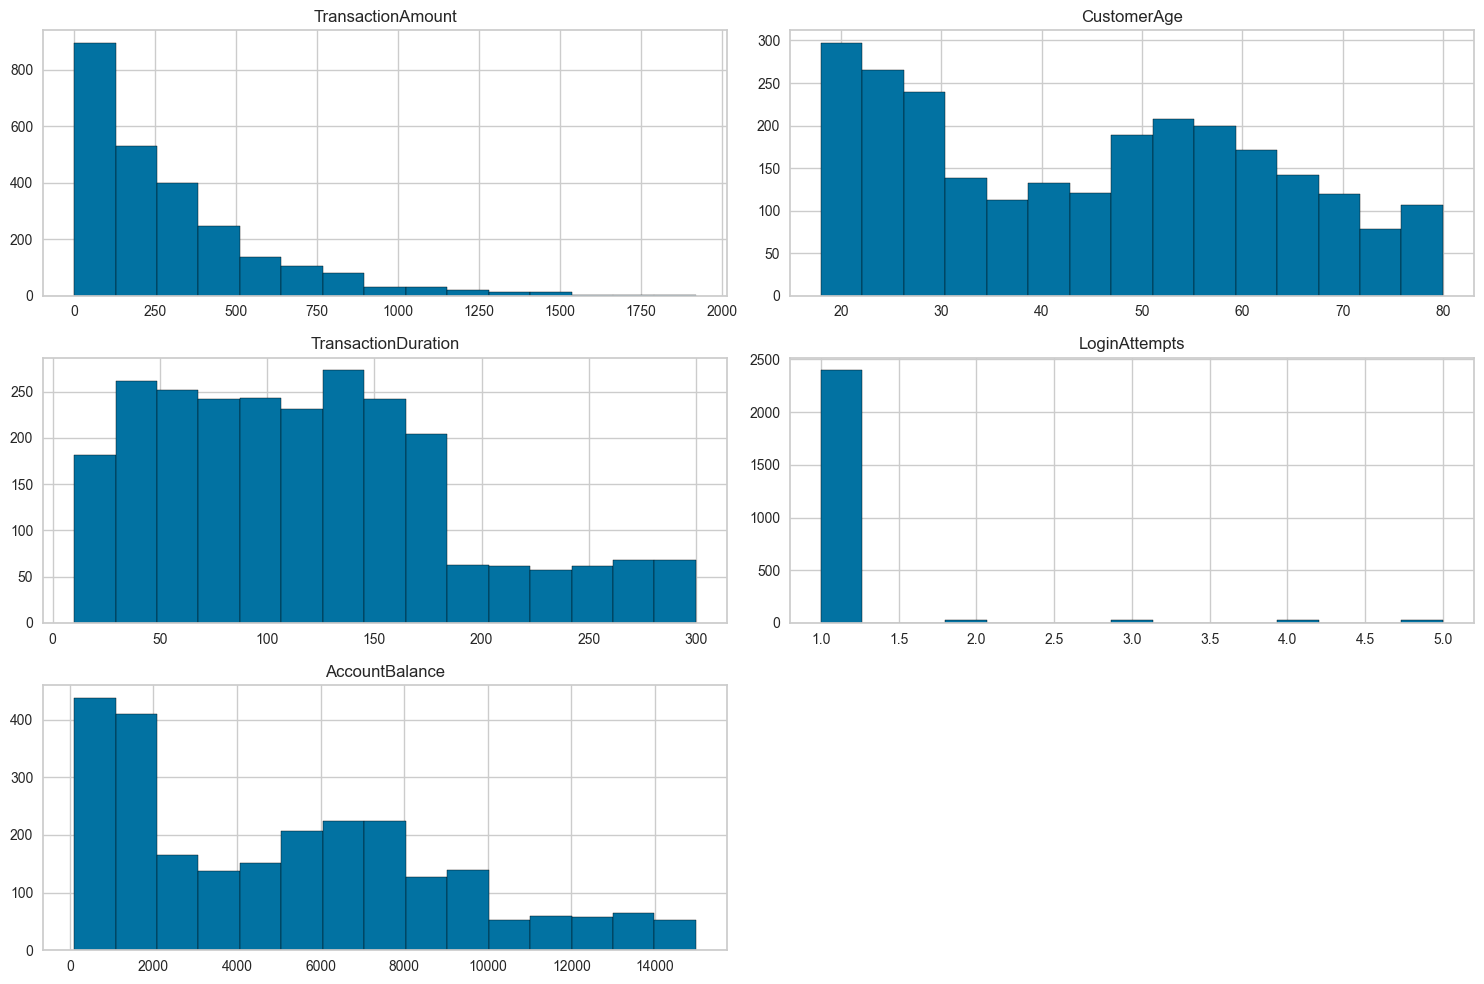

In [151]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
df[numeric_cols].hist(bins=15, figsize=(15, 10), edgecolor='black')
plt.tight_layout()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

Text(0.5, 1.02, 'Pairplot of Numerical Features')

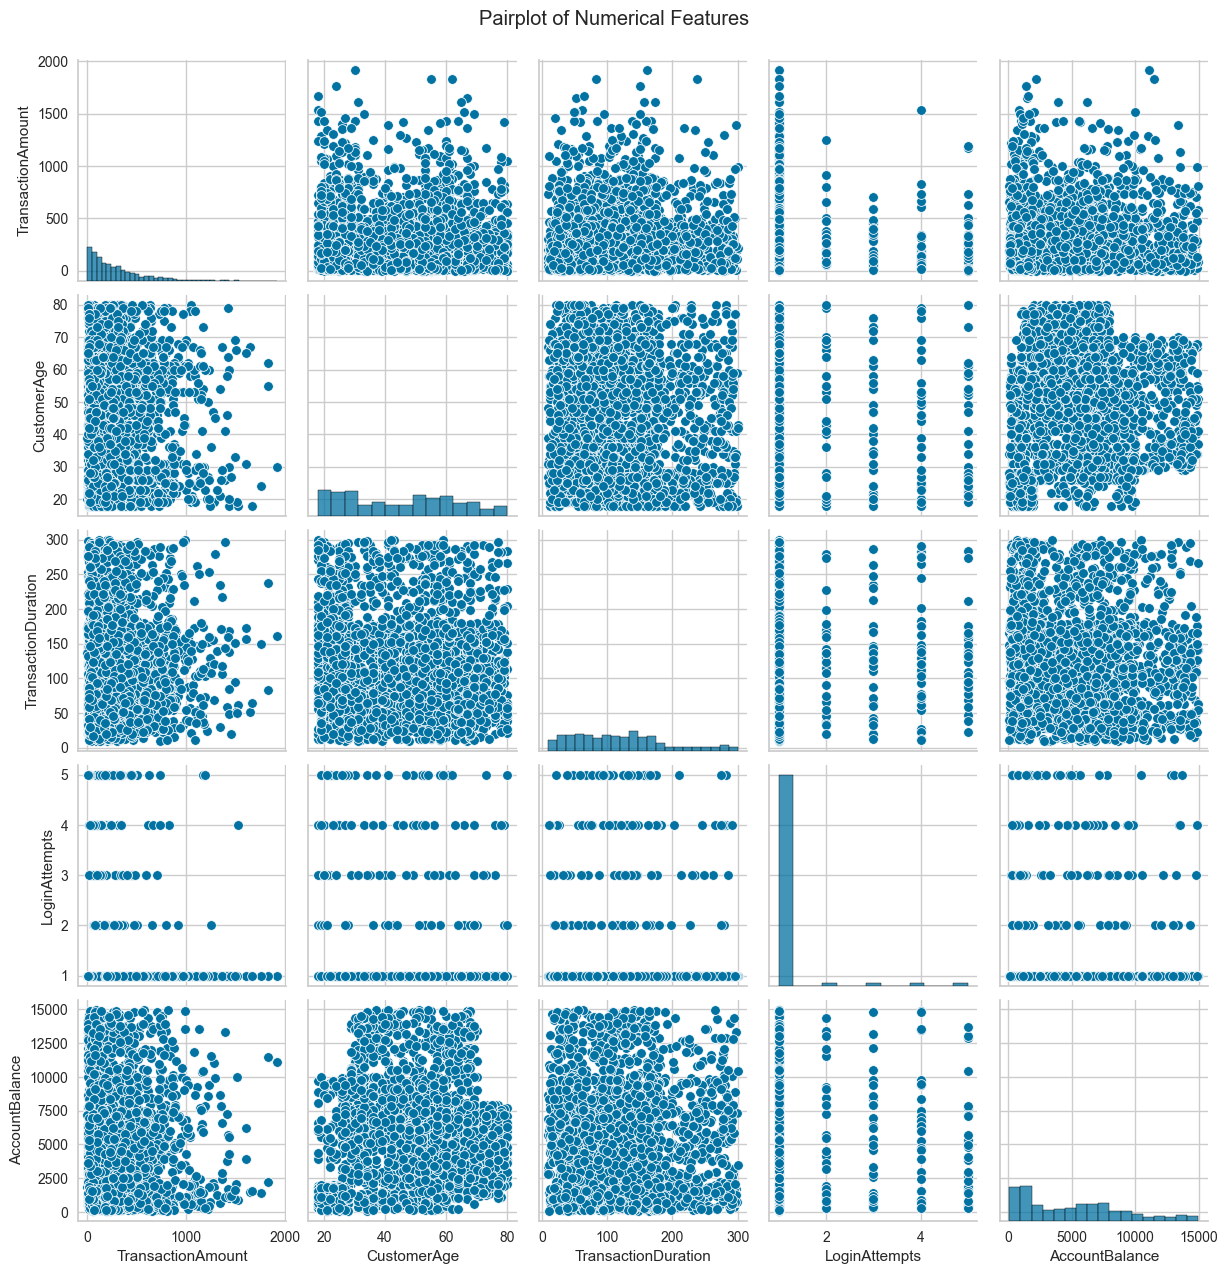

In [152]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
sns.pairplot(df[numeric_cols])
plt.suptitle('Pairplot of Numerical Features', y=1.02)


# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [153]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

In [154]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [155]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,-0.970546,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,1.419862,Doctor,-0.548393,-0.204629,-0.000315,2024-11-04 08:08:08
1,TX000002,AC00455,0.268963,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,1.307715,Doctor,0.307960,-0.204629,2.218381,2024-11-04 08:09:35
2,TX000003,AC00019,-0.586526,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,-1.439874,Student,-0.905207,-0.204629,-1.024091,2024-11-04 08:07:04
3,TX000004,AC00070,-0.387294,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,-1.047361,Student,-1.347656,-0.204629,0.886694,2024-11-04 08:09:06
4,TX000005,AC00411,-0.972736,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,1.121495,-0.204629,0.594263,2024-11-04 08:06:39


In [156]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
df = df.drop(columns=['TransactionID', 'IP Address', 'AccountID', 'DeviceID', 'MerchantID'])
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,-0.970546,2023-04-11 16:29:14,Debit,San Diego,ATM,1.419862,Doctor,-0.548393,-0.204629,-0.000315,2024-11-04 08:08:08
1,0.268963,2023-06-27 16:44:19,Debit,Houston,ATM,1.307715,Doctor,0.307960,-0.204629,2.218381,2024-11-04 08:09:35
2,-0.586526,2023-07-10 18:16:08,Debit,Mesa,Online,-1.439874,Student,-0.905207,-0.204629,-1.024091,2024-11-04 08:07:04
3,-0.387294,2023-05-05 16:32:11,Debit,Raleigh,Online,-1.047361,Student,-1.347656,-0.204629,0.886694,2024-11-04 08:09:06
4,-0.972736,2023-10-16 17:51:24,Credit,Atlanta,Online,NaN,Student,1.121495,-0.204629,0.594263,2024-11-04 08:06:39


In [157]:
encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le 
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,-0.970546,680,1,36,0,1.419862,0,-0.548393,-0.204629,-0.000315,105
1,0.268963,1178,1,15,0,1.307715,0,0.307960,-0.204629,2.218381,192
2,-0.586526,1262,1,23,2,-1.439874,3,-0.905207,-0.204629,-1.024091,41
3,-0.387294,818,1,33,2,-1.047361,3,-1.347656,-0.204629,0.886694,163
4,-0.972736,1939,0,1,2,NaN,3,1.121495,-0.204629,0.594263,16


In [158]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
df.columns.tolist()

['TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [159]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
df = df.dropna()
df.isnull().sum()


TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [160]:
# Menghapus data duplikat menggunakan drop_duplicates().
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [161]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[outlier_mask]
df.shape

(2183, 11)

In [162]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [163]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df.describe()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2183.000000,2183.000000,2183.000000,2183.000000,2183.000000,2183.000000,2183.000000,2183.000000,2183.000000,2183.000000,2183.000000
mean,-0.142953,1253.670179,0.788823,21.472744,1.012368,-0.002339,1.531837,-0.008972,-0.204629,-0.003221,180.975263
std,0.743083,724.690314,0.440631,12.448282,0.827646,0.994962,1.152357,1.000449,0.000000,0.996433,103.558475
min,-1.017881,0.000000,0.000000,0.000000,0.000000,-1.495947,0.000000,-1.561745,-0.204629,-1.286100,0.000000
25%,-0.751018,629.500000,1.000000,11.000000,0.000000,-0.991288,0.000000,-0.812436,-0.204629,-0.926136,93.000000
50%,-0.336331,1247.000000,1.000000,22.000000,1.000000,0.018031,2.000000,-0.134489,-0.204629,-0.101336,181.000000
75%,0.267611,1879.500000,1.000000,32.000000,2.000000,0.803056,3.000000,0.600547,-0.204629,0.646712,271.000000
max,2.072523,2485.000000,2.000000,43.000000,3.000000,1.980594,4.000000,2.577295,-0.204629,2.531190,360.000000


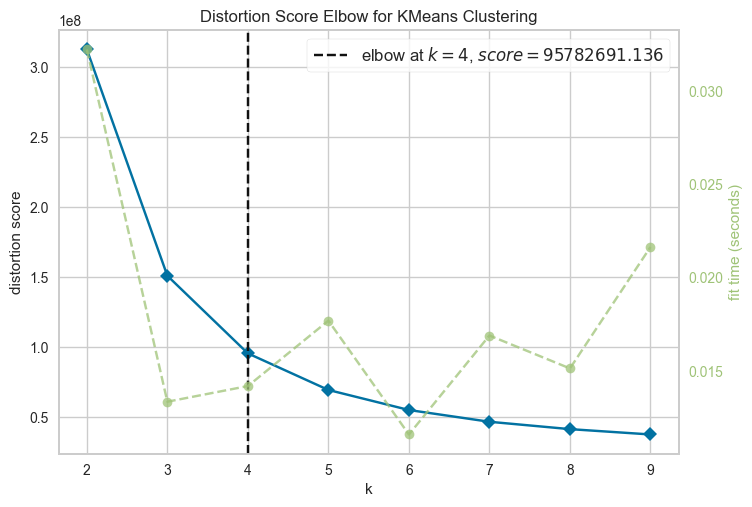

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [164]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,10))
visualizer.fit(df)
visualizer.show()

In [165]:
# Menggunakan algoritma K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Cluster
0,-0.970546,680,1,36,0,1.419862,0,-0.548393,-0.204629,-0.000315,105,3
1,0.268963,1178,1,15,0,1.307715,0,0.307960,-0.204629,2.218381,192,3
2,-0.586526,1262,1,23,2,-1.439874,3,-0.905207,-0.204629,-1.024091,41,2
3,-0.387294,818,1,33,2,-1.047361,3,-1.347656,-0.204629,0.886694,163,3
5,-0.703375,635,1,28,0,-1.495947,3,0.750409,-0.204629,-1.111505,13,3


Jalankan cell code ini untuk menyimpan model kamu.

In [166]:
# Menyimpan model menggunakan joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [167]:
# Menghitung dan menampilkan nilai Silhouette Score.
score = silhouette_score(df.drop(columns=['Cluster']), df['Cluster'])
score

0.49798605264367046

Text(0.5, 1.0, 'Clustering Results')

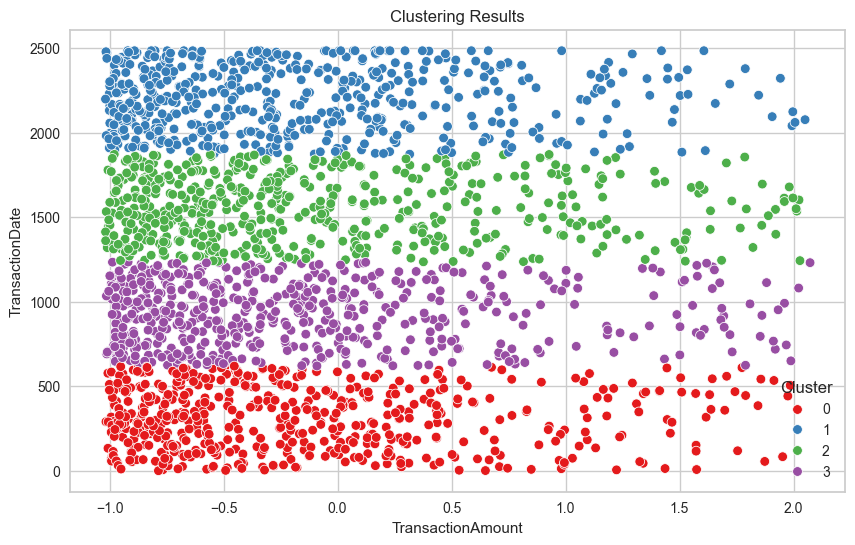

In [168]:
# Membuat visualisasi hasil clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 1], hue=df['Cluster'], palette='Set1')
plt.title('Clustering Results')

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [169]:
# Membangun model menggunakan PCA.
# ___ =PCA(n_components=<x>)
# ___ = ____.fit_transform(___)
# Menyimpan data PCA sebagai Dataframe dengan nama PCA_<numbers>
# <data_final> = pd.DataFrame(___, columns=['PCA1', 'PCA2', <sesuaikan dengan jumlah n>])
# Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
# ___ = KMeans(n_clusters=<x>)
# ___.fit(<data_final>)

In [170]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
# joblib.dump(___, "PCA_model_clustering.h5")

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [171]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.
df.rename(columns={'Cluster': 'Target'}, inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns.drop("Target", errors="ignore")

numeric_summary = df.groupby("Target")[num_cols].agg(["mean", "min", "max", "median", "std"])

pd.set_option("display.max_columns", None)  
pd.set_option("display.width", None)  

display(numeric_summary)

TransactionAmount                                          \
                    mean       min       max    median       std   
Target                                                             
0              -0.145908 -1.015827  1.985656 -0.329075  0.738657   
1              -0.180011 -1.017881  2.050618 -0.325721  0.707390   
2              -0.093775 -1.017676  2.028200 -0.314905  0.772287   
3              -0.151983 -1.013945  2.072523 -0.367887  0.752125   

       TransactionDate                                 TransactionType      \
                  mean   min   max  median         std            mean min   
Target                                                                       
0           310.753731     0   619   311.5  179.680680        0.809701   0   
1          2195.703436  1873  2485  2200.0  185.218141        0.772152   0   
2          1550.087432  1236  1872  1546.0  183.876515        0.790528   0   
3           926.561468   620  1235   926.0  178.560009        0.783486   0   

                              Location                             Channel  \
       max median       std       mean min max median        std      mean   
Target                                                                       
0        2    1.0  0.424901  21.690299   0  43   22.0  12.510376  0.983209   
1        2    1.0  0.440872  21.632911   0  43   22.0  12.512492  1.063291   
2        2    1.0  0.449880  21.111111   0  43   21.0  12.338609  0.990893   
3        2    1.0  0.446497  21.460550   0  43   22.0  12.457826  1.011009   

                                CustomerAge                                \
       min max median       std        mean       min       max    median   
Target                                                                      
0        0   3    1.0  0.816705   -0.077064 -1.495947  1.980594 -0.206262   
1        0   3    1.0  0.832737    0.017828 -1.495947  1.980594  0.074104   
2        0   3    1.0  0.840310    0.027836 -1.495947  1.980594  0.074104   
3        0   3    1.0  0.820166    0.020294 -1.495947  1.980594  0.074104   

                 CustomerOccupation                           \
             std               mean min max median       std   
Target                                                         
0       0.978143           1.513060   0   4    1.0  1.147047   
1       0.982714           1.502712   0   4    1.0  1.147024   
2       1.013656           1.582878   0   4    2.0  1.147418   
3       1.003717           1.528440   0   4    2.0  1.169314   

       TransactionDuration                                          \
                      mean       min       max    median       std   
Target                                                               
0                -0.044434 -1.561745  2.563023 -0.163034  1.001086   
1                 0.004907 -1.561745  2.577295 -0.163034  1.013720   
2                 0.013410 -1.561745  2.563023 -0.077399  0.994567   
3                -0.010724 -1.561745  2.548750 -0.077399  0.993940   

       LoginAttempts                                    AccountBalance  \
                mean       min       max    median  std           mean   
Target                                                                   
0          -0.204629 -0.204629 -0.204629 -0.204629  0.0      -0.031907   
1          -0.204629 -0.204629 -0.204629 -0.204629  0.0       0.032202   
2          -0.204629 -0.204629 -0.204629 -0.204629  0.0      -0.007655   
3          -0.204629 -0.204629 -0.204629 -0.204629  0.0      -0.006485   

                                               PreviousTransactionDate      \
             min       max    median       std                    mean min   
Target                                                                       
0      -1.285856  2.522155 -0.122899  0.977648              186.837687   0   
1      -1.274746  2.531190 -0.059819  1.005547              182.009042   0   
2      -1.286100  2.520287 -0.095927  0.971158 

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.

**Cluster 0**
- TransactionAmount: mean = -0.15, min = -1.02, max = 1.99 → transaksi relatif **sedang**.
- TransactionDate: mean = 311 hari, min = 0, max = 619 → transaksi cenderung terjadi lebih **awal** dibanding cluster lain.
- TransactionType: mean ≈ 0.81 → dominan **Debit**.
- Location: mean ≈ 21.7 → tersebar, tidak terpusat pada lokasi tertentu.
- Channel: mean ≈ 0.98 → dominan **Channel cabang**.
- CustomerAge: mean = -0.08 → mayoritas usia relatif **lebih muda**.
- CustomerOccupation: mean ≈ 1.51 → dominan **pekerjaan level rendah-menengah**.
- TransactionDuration: mean ≈ -0.04 → transaksi relatif **cepat**.
- LoginAttempts: konsisten -0.20 → **hanya 1 kali login**.
- AccountBalance: mean = -0.03, min = -1.29, max = 2.52 → saldo **sedang**.
- PreviousTransactionDate: mean ≈ 187 hari → transaksi relatif **baru**.
- **Analisis:** Nasabah dengan usia lebih muda, transaksi debit lewat cabang, saldo sedang, transaksi cepat. Potensial ditawarkan produk **tabungan digital**.

---

**Cluster 1**
- TransactionAmount: mean = -0.18, min = -1.02, max = 2.05 → transaksi relatif **rendah-sedang**.
- TransactionDate: mean = 2196 hari, min = 1873, max = 2485 → transaksi **lebih baru**.
- TransactionType: mean ≈ 0.77 → dominan **Debit**.
- Location: mean ≈ 21.6 → tersebar.
- Channel: mean ≈ 1.06 → dominan **ATM/cabang**.
- CustomerAge: mean = 0.02 → usia rata-rata sedikit lebih **tua**.
- CustomerOccupation: mean ≈ 1.50 → dominan pekerjaan **menengah**.
- TransactionDuration: mean ≈ 0.00 → transaksi normal.
- LoginAttempts: konsisten -0.20 → **1 kali login**.
- AccountBalance: mean = 0.03 → saldo relatif **lebih tinggi** dari cluster lain.
- PreviousTransactionDate: mean = 182 hari → transaksi **cukup baru**.
- **Analisis:** Nasabah dengan saldo lebih tinggi, transaksi debit lewat cabang/ATM, usia menengah. Cocok ditawarkan **investasi ringan**.

---

**Cluster 2**
- TransactionAmount: mean = -0.09, min = -1.02, max = 2.03 → transaksi relatif **sedang**.
- TransactionDate: mean = 1550 hari, min = 1236, max = 1872 → transaksi **lama**.
- TransactionType: mean ≈ 0.79 → dominan **Debit**.
- Location: mean ≈ 21.1 → tersebar.
- Channel: mean ≈ 0.99 → dominan **Cabang**.
- CustomerAge: mean = 0.03 → usia relatif **dewasa**.
- CustomerOccupation: mean ≈ 1.58 → dominan **pekerjaan lebih tinggi**.
- TransactionDuration: mean ≈ 0.01 → normal.
- LoginAttempts: konsisten -0.20 → **1 kali login**.
- AccountBalance: mean = -0.01 → saldo relatif **sedang**.
- PreviousTransactionDate: mean = 182 hari → transaksi cukup **baru**.
- **Analisis:** Nasabah berusia dewasa dengan pekerjaan lebih tinggi, transaksi debit lama namun masih aktif. Potensial ditawarkan **kredit investasi / produk premium**.

---

**Cluster 3**
- TransactionAmount: mean = -0.15, min = -1.01, max = 2.07 → transaksi **sedang**.
- TransactionDate: mean = 927 hari, min = 620, max = 1235 → transaksi **menengah**.
- TransactionType: mean ≈ 0.78 → dominan **Debit**.
- Location: mean ≈ 21.5 → tersebar.
- Channel: mean ≈ 1.01 → dominan **ATM/cabang**.
- CustomerAge: mean = 0.02 → usia relatif **paruh baya**.
- CustomerOccupation: mean ≈ 1.53 → dominan pekerjaan **menengah**.
- TransactionDuration: mean ≈ -0.01 → transaksi normal.
- LoginAttempts: konsisten -0.20 → **1 kali login**.
- AccountBalance: mean = -0.01 → saldo relatif **sedang**.
- PreviousTransactionDate: mean = 173 hari → transaksi **baru**.
- **Analisis:** Nasabah paruh baya, transaksi debit reguler, saldo sedang, lokasi bervariasi. Cocok ditawarkan produk **tabungan stabilitas / proteksi keuangan**.


# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [172]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df.rename(columns={'Cluster': 'Target'}, inplace=True)
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Target
0,-0.970546,680,1,36,0,1.419862,0,-0.548393,-0.204629,-0.000315,105,3
1,0.268963,1178,1,15,0,1.307715,0,0.307960,-0.204629,2.218381,192,3
2,-0.586526,1262,1,23,2,-1.439874,3,-0.905207,-0.204629,-1.024091,41,2
3,-0.387294,818,1,33,2,-1.047361,3,-1.347656,-0.204629,0.886694,163,3
5,-0.703375,635,1,28,0,-1.495947,3,0.750409,-0.204629,-1.111505,13,3


In [173]:
# Simpan Data
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [174]:
# inverse dataset ke rentang normal untuk numerikal
df[numeric_cols] = scaler.inverse_transform(df[numeric_cols])
# tampilkan dataset yang sudah di-inverse
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Target
0,14.09,680,1,36,0,70.0,0,81.0,1.0,5112.21,105,3
1,376.24,1178,1,15,0,68.0,0,141.0,1.0,13758.91,192,3
2,126.29,1262,1,23,2,19.0,3,56.0,1.0,1122.35,41,2
3,184.50,818,1,33,2,26.0,3,25.0,1.0,8569.06,163,3
5,92.15,635,1,28,0,18.0,3,172.0,1.0,781.68,13,3


In [175]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)
categorical_cols = df.select_dtypes(include=['object']).columns
for col, le in encoders.items():
    df[col] = le.inverse_transform(df[col])
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,3
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,3
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,2
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,3
5,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36,3


In [176]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.
agg_dict = {}

for col in df.columns:
    if col != "Target":
        if np.issubdtype(df[col].dtype, np.number):  
            agg_dict[col] = ['mean', 'min', 'max']
        else:
            agg_dict[col] = [("mode", lambda x: x.mode()[0] if not x.mode().empty else np.nan)]

result = df.groupby('Target').agg(agg_dict)

pd.set_option("display.max_columns", None)  
pd.set_option("display.width", None)  

result

TransactionAmount                    TransactionDate TransactionType  \
                    mean   min     max                 mode            mode   
Target                                                                        
0             255.026231  0.86  877.81  2023-01-02 16:00:06           Debit   
1             245.062260  0.26  896.79  2023-12-28 17:31:03           Debit   
2             270.258106  0.32  890.24  2023-07-07 16:11:38           Debit   
3             253.251321  1.41  903.19  2023-04-03 16:07:53           Debit   

       Location Channel CustomerAge             CustomerOccupation  \
           mode    mode        mean   min   max               mode   
Target                                                               
0        Boston  Branch   43.304104  18.0  80.0            Student   
1          Mesa  Branch   44.996383  18.0  80.0             Doctor   
2       Houston     ATM   45.174863  18.0  80.0            Student   
3        Fresno  Branch   45.040367  18.0  80.0            Student   

       TransactionDuration              LoginAttempts            \
                      mean   min    max          mean  min  max   
Target                                                            
0               116.309701  10.0  299.0           1.0  1.0  1.0   
1               119.766727  10.0  300.0           1.0  1.0  1.0   
2               120.362477  10.0  299.0           1.0  1.0  1.0   
3               118.671560  10.0  298.0           1.0  1.0  1.0   

       AccountBalance                   PreviousTransactionDate  
                 mean     min       max                    mode  
Target                                                           
0         4989.090896  102.20  14942.78     2024-11-04 08:10:23  
1         5238.937559  145.50  14977.99     2024-11-04 08:07:50  
2         5083.604918  101.25  14935.50     2024-11-04 08:07:32  
3         5088.164642  106.86  14904.90     2024-11-04 08:09:03

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.

## Cluster 0
- **TransactionAmount**: mean = 255.03, min = 0.86, max = 877.81 → transaksi kategori sedang.
- **TransactionType**: Debit.
- **Location dominan**: Boston.
- **Channel dominan**: Branch.
- **CustomerAge**: mean = 43.3, min = 18, max = 80 → nasabah usia paruh baya.
- **TransactionDuration**: mean = 116 detik, min = 10, max = 299.
- **LoginAttempts**: selalu 1.
- **AccountBalance**: mean = 4,989, min = 102, max = 14,943.
- **PreviousTransactionDate**: rata-rata 2024-11-04 → transaksi relatif baru.
- **Analisis**: Nasabah dengan saldo menengah ke atas, transaksi debit melalui cabang, dan usia paruh baya. Cocok ditawarkan produk tabungan atau investasi jangka menengah.

---

## Cluster 1
- **TransactionAmount**: mean = 245.06, min = 0.26, max = 896.79 → transaksi relatif lebih kecil dibanding cluster lain.
- **TransactionType**: Debit.
- **Location dominan**: Mesa.
- **Channel dominan**: Branch.
- **CustomerAge**: mean = 45.0, min = 18, max = 80 → cenderung lebih tua.
- **TransactionDuration**: mean = 119 detik, min = 10, max = 300.
- **LoginAttempts**: selalu 1.
- **AccountBalance**: mean = 5,239, min = 146, max = 14,978.
- **PreviousTransactionDate**: rata-rata 2024-11-04.
- **Analisis**: Nasabah berusia lebih senior, saldo relatif tinggi, dan transaksi debit melalui cabang. Potensial untuk produk simpanan jangka panjang atau layanan premium.

---

## Cluster 2
- **TransactionAmount**: mean = 270.26, min = 0.32, max = 890.24 → transaksi relatif besar.
- **TransactionType**: Debit.
- **Location dominan**: Houston.
- **Channel dominan**: ATM.
- **CustomerAge**: mean = 45.2, min = 18, max = 80.
- **TransactionDuration**: mean = 120 detik, min = 10, max = 299.
- **LoginAttempts**: selalu 1.
- **AccountBalance**: mean = 5,084, min = 101, max = 14,936.
- **PreviousTransactionDate**: rata-rata 2024-11-04.
- **Analisis**: Nasabah sering menggunakan ATM dengan nilai transaksi relatif besar. Cocok untuk ditawarkan produk digital banking atau layanan transaksi cepat.

---

## Cluster 3
- **TransactionAmount**: mean = 253.25, min = 1.41, max = 903.19.
- **TransactionType**: Debit.
- **Location dominan**: Fresno.
- **Channel dominan**: Branch.
- **CustomerAge**: mean = 45.0, min = 18, max = 80.
- **TransactionDuration**: mean = 118 detik, min = 10, max = 298.
- **LoginAttempts**: selalu 1.
- **AccountBalance**: mean = 5,088, min = 107, max = 14,905.
- **PreviousTransactionDate**: rata-rata 2024-11-04.
- **Analisis**: Nasabah transaksi debit lewat cabang dengan nominal cukup stabil. Segmentasi ini cocok untuk layanan perbankan tradisional atau program loyalitas cabang.


(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [177]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
df_final = df.copy()
df_final.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,3
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,3
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,2
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,3
5,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36,3


In [178]:
# Simpan Data
df_final.to_csv('data_clustering_inverse.csv', index=False)

End of Code.